# Gemstone Classification using Deep Learning

## A gemstone (gem, fine gem, jewel, precious stone, or semi-precious stone) is a piece of mineral crystal which, in cut and polished form, is used to make jewelry or other adornments. In this notebook, we will be classifying the type of gemstone based on the given image.

### import libraries

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import wget
import os
import cv2
from random import randint

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.python.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, log_loss, accuracy_score
from sklearn.model_selection import train_test_split

In [ ]:
!pip install wget

  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9672 sha256=47a6fa87f7a936f145b6947437c7d75bede6974dbd72f71e00112fae949b226c
  Stored in directory: /root/.cache/pip/wheels/a1/b6/7c/0e63e34eb06634181c63adacca38b79ff8f35c37e3c13e3c02
Successfully built wget


###Unzip the dataset to use in our notebook

In [ ]:
!wget -N "https://cainvas-static.s3.amazonaws.com/media/user_data/cainvas-admin/gemstones.zip"
!unzip -qo gemstones.zip

--2021-08-18 14:09:11--  https://cainvas-static.s3.amazonaws.com/media/user_data/cainvas-admin/gemstones.zip
Resolving cainvas-static.s3.amazonaws.com (cainvas-static.s3.amazonaws.com)... 52.219.64.72
Connecting to cainvas-static.s3.amazonaws.com (cainvas-static.s3.amazonaws.com)|52.219.64.72|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24678423 (24M) [application/x-zip-compressed]
Saving to: ‘gemstones.zip’

gemstones.zip       100%[===================>]  23.54M  11.4MB/s    in 2.1s    

2021-08-18 14:09:14 (11.4 MB/s) - ‘gemstones.zip’ saved [24678423/24678423]



In [ ]:
directory = 'gemstones/train/'

In [ ]:
#printing all the gemstone categories present in our dataset
Name=[]
for file in os.listdir(directory):
    Name+=[file]
print(Name)
print(len(Name))

['Ametrine', 'Morganite', 'Andradite', 'Dumortierite', 'Quartz Rose', 'Hessonite', 'Iolite', 'Topaz', 'Zoisite', 'Rhodochrosite', 'Diamond', 'Chrome Diopside', 'Spodumene', 'Larimar', 'Quartz Beer', 'Chrysoberyl', 'Emerald', 'Carnelian', 'Sunstone', 'Chalcedony', 'Andalusite', 'Tigers Eye', 'Prehnite', 'Lapis Lazuli', 'Spinel', 'Danburite', 'Aventurine Green', 'Sapphire Pink', 'Variscite', 'Cats Eye', 'Sapphire Yellow', 'Serpentine', 'Blue Lace Agate', 'Chrysoprase', 'Ruby', 'Aventurine Yellow', 'Quartz Smoky', 'Onyx Red', 'Peridot', 'Alexandrite']
40


###Map and display all the categories present in our dataset. There are total 68 different kinds of gemstones.

In [ ]:
gems_map = dict(zip(Name, [t for t in range(len(Name))]))
print(gems_map)
r_gems_map=dict(zip([t for t in range(len(Name))],Name)) 

{'Ametrine': 0, 'Morganite': 1, 'Andradite': 2, 'Dumortierite': 3, 'Quartz Rose': 4, 'Hessonite': 5, 'Iolite': 6, 'Topaz': 7, 'Zoisite': 8, 'Rhodochrosite': 9, 'Diamond': 10, 'Chrome Diopside': 11, 'Spodumene': 12, 'Larimar': 13, 'Quartz Beer': 14, 'Chrysoberyl': 15, 'Emerald': 16, 'Carnelian': 17, 'Sunstone': 18, 'Chalcedony': 19, 'Andalusite': 20, 'Tigers Eye': 21, 'Prehnite': 22, 'Lapis Lazuli': 23, 'Spinel': 24, 'Danburite': 25, 'Aventurine Green': 26, 'Sapphire Pink': 27, 'Variscite': 28, 'Cats Eye': 29, 'Sapphire Yellow': 30, 'Serpentine': 31, 'Blue Lace Agate': 32, 'Chrysoprase': 33, 'Ruby': 34, 'Aventurine Yellow': 35, 'Quartz Smoky': 36, 'Onyx Red': 37, 'Peridot': 38, 'Alexandrite': 39}


In [ ]:
img_w, img_h = 100, 100

###Create functions to read images and labels of gemstones from the training dataset.

In [ ]:
#function which reads images and class names
def read_images():
    Images, Labels = [], []
    for root, dirs, files in os.walk('gemstones/train/'):
        f = os.path.basename(root)        
        for file in files:
            Labels.append(f)
            try:
                image = cv2.imread(root+'/'+file)              # read the image (OpenCV)
                image = cv2.resize(image,(int(img_w), int(img_h)))       # resize the image (images are different sizes)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # converts an image from BGR color space to RGB
                Images.append(image)
            except Exception as e:
                print(e)
    Images = np.array(Images)
    return (Images,Labels)

In [ ]:
#function which converts string labels to numbers
def get_class_index(Labels):
    for i, n in enumerate(Labels):
        for j, k in enumerate(Name):    
            if n == k:
                Labels[i] = j
    Labels = np.array(Labels)
    return Labels  

###Read images and labels from the training set

In [ ]:
Train_Imgs, Train_Lbls = read_images()
Train_Lbls = get_class_index(Train_Lbls)
print('Shape of train images: {}'.format(Train_Imgs.shape))
print('Shape of train labels: {}'.format(Train_Lbls.shape))

Shape of train images: (1303, 100, 100, 3)
Shape of train labels: (1303,)


###Printing some random images from the gemstone training set.

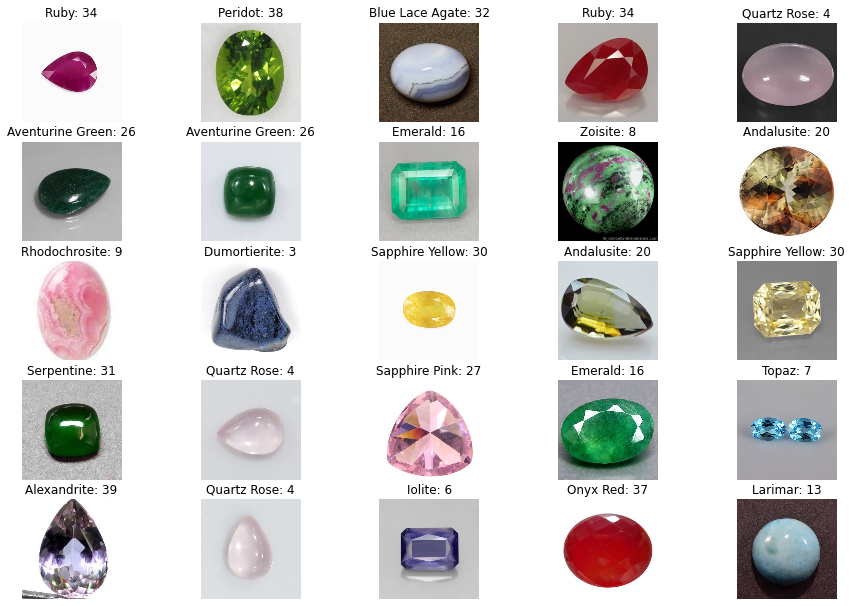

In [ ]:
dim = 5

f,ax = plt.subplots(dim,dim) 
f.subplots_adjust(0,0,2,2)
for i in range(0,dim):
    for j in range(0,dim):
        rnd_number = randint(0,len(Train_Imgs))
        cl = Train_Lbls[rnd_number]
        ax[i,j].imshow(Train_Imgs[rnd_number])
        ax[i,j].set_title(Name[cl]+': ' + str(cl))
        ax[i,j].axis('off')

### Split the training dataset into train and validation sets.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(Train_Imgs, Train_Lbls, shuffle = True, test_size = 0.2, random_state = 42)
print('Shape of X_train: {}, y_train: {} '.format(X_train.shape, y_train.shape))
print('Shape of X_val: {}, y_val: {} '.format(X_val.shape, y_val.shape))

Shape of X_train: (1042, 100, 100, 3), y_train: (1042,) 
Shape of X_val: (261, 100, 100, 3), y_val: (261,) 


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Dropout,Flatten,Activation,BatchNormalization, AveragePooling2D
from tensorflow.keras.models import model_from_json
from tensorflow.keras.models import load_model

###Create a sequential model.

In [ ]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3,3),input_shape=(100,100,3), activation='relu', padding = 'same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding = 'same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding = 'same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding = 'same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding = 'same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding = 'same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(256))
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(len(gems_map)))
model.add(Activation('softmax'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_6 (Conv2D)            (None, 100, 100, 32)      896       
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 50, 50, 32)        0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 50, 50, 64)        18496     
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (None, 25, 25, 64)        0         
_________________________________________________________________
conv2d_8 (Conv2D)            (None, 25, 25, 64)        36928     
_________________________________________________________________
max_pooling2d_8 (MaxPooling2 (None, 12, 12, 64)        0         
_________________________________________________________________
conv2d_9 (Conv2D)            (None, 12, 12, 64)       

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

###Perform data augmentation on the images so that we can achieve more relevant data.

In [ ]:
train_datagen = ImageDataGenerator(vertical_flip=True,
                                horizontal_flip=True,
                                rotation_range=40,
                                width_shift_range=0.2,
                                height_shift_range=0.2,
                                zoom_range=0.1,
                                validation_split=0.2)

val_datagen = ImageDataGenerator()

In [ ]:
batch_size = 32

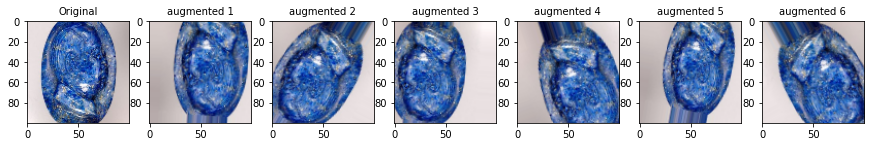

In [ ]:
n = randint(0,len(X_train))
samples = np.expand_dims(X_train[n], 0)
it = train_datagen.flow(samples, batch_size=batch_size)
cols = 7

fig, ax = plt.subplots(nrows=1, ncols=cols, figsize=(15, 10))
ax[0].imshow(X_train[n], cmap='gray')
ax[0].set_title('Original', fontsize=10)

for i in range(1,cols):
    batch = it.next()    # generate batch of images 
    image = batch[0].astype('uint32') # convert to unsigned int for viewing
    ax[i].set_title('augmented {}'.format(i), fontsize=10)
    ax[i].imshow(image, cmap='gray')

In [ ]:
train_gen = train_datagen.flow(X_train, y_train, batch_size=batch_size)
val_gen = val_datagen.flow(X_val, y_val, batch_size=batch_size)

In [ ]:
EPOCHS = 80                           
iter_per_epoch = len(X_train) // batch_size  
val_per_epoch = len(X_val) // batch_size

###Train the sequential model.

In [ ]:
m = model.fit(
       train_gen,
       steps_per_epoch= iter_per_epoch,
       epochs=EPOCHS, 
       validation_data = val_gen,
       validation_steps = val_per_epoch,
       verbose = 1 
       )

Epoch 1/80
32/32 [==============================] - 33s 117ms/step - loss: 5.1571 - accuracy: 0.0178 - val_loss: 3.6625 - val_accuracy: 0.0547
Epoch 2/80
32/32 [==============================] - 3s 105ms/step - loss: 3.6005 - accuracy: 0.0663 - val_loss: 3.3775 - val_accuracy: 0.1250
Epoch 3/80
32/32 [==============================] - 3s 105ms/step - loss: 3.2907 - accuracy: 0.0970 - val_loss: 3.0408 - val_accuracy: 0.1250
Epoch 4/80
32/32 [==============================] - 3s 105ms/step - loss: 3.0124 - accuracy: 0.1386 - val_loss: 2.7605 - val_accuracy: 0.1641
Epoch 5/80
32/32 [==============================] - 3s 105ms/step - loss: 2.7256 - accuracy: 0.2020 - val_loss: 2.2371 - val_accuracy: 0.2852
Epoch 6/80
32/32 [==============================] - 3s 105ms/step - loss: 2.2337 - accuracy: 0.3069 - val_loss: 1.6973 - val_accuracy: 0.4141
Epoch 7/80
32/32 [==============================] - 3s 106ms/step - loss: 1.9693 - accuracy: 0.3799 - val_loss: 1.7068 - val_accuracy: 0.4258
Epoch

###Plot accuracy and loss graphs to evaluate the performance of our model.

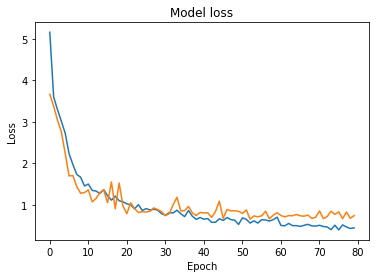

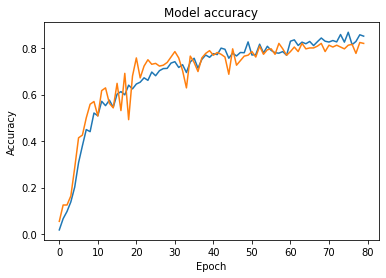

In [ ]:
plt.plot(m.history['loss'])
plt.plot(m.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model loss')
plt.show()

plt.plot(m.history['accuracy'])
plt.plot(m.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model accuracy')
plt.show()

In [ ]:
model.save('saved_models/gemstone.tf')

INFO:tensorflow:Assets written to: saved_models/gemstone.tf/assets
